# Part II — Optimal Trajectory Tracking

This notebook implements the finite-horizon **tracking LQR** problem from Section 6 of the 270C final project:

$$
\min_{u}\; \int_0^{t_f} \big[(x - x_{\mathrm{ref}})^\top Q (x - x_{\mathrm{ref}}) + u^\top R u\big]\, dt
$$

subject to the **linearized lander dynamics** from Part I,
$$
\dot x = A(t)\, x + B(t)\, u, \qquad x(t_f)\ \text{free}.
$$

State (deviations from trim): $x = [p_x, p_z, v_x, v_z, \theta, \omega, m]^\top$, control $u = [\delta T, \tau]^\top$.

---

## Thought process / roadmap

1. **Generate a reference** $x_{\mathrm{ref}}(t)$ by solving the Part I *regulation* problem (same $Q,R$ but cost on $x$ rather than $x-x_{\mathrm{ref}}$). This is the "pre-planned mission segment" the vehicle should rejoin.
2. **Derive the tracking PMP conditions** — the Hamiltonian picks up the offset $(x-x_{\mathrm{ref}})$ in the state penalty, which propagates into an *inhomogeneous* adjoint and a **feedforward term** $s(t)$ alongside the familiar Riccati matrix $P(t)$.
3. **Integrate the Riccati and feedforward ODEs backward** from $t_f$ (with $P(t_f)=0$, $s(t_f)=0$ because the terminal state is free and there is no terminal cost in Part II).
4. **Simulate closed-loop tracking** from a **substantially different** initial condition — not a small perturbation of the reference.
5. **Analyze** tracking error, transients, control effort, and robustness to perturbations in $x_0$ and $x_{\mathrm{ref}}$.

---

## PMP derivation (tracking vs regulation)

Hamiltonian:
$$
H = (x-x_{\mathrm{ref}})^\top Q (x-x_{\mathrm{ref}}) + u^\top R u + \lambda^\top (Ax + Bu).
$$

**Stationarity** ($\partial H/\partial u = 0$):
$$
u^*(t) = -R^{-1} B(t)^\top \lambda(t).
$$

**Adjoint** ($\dot\lambda = -\partial H/\partial x$):
$$
-\dot\lambda = 2Q(x - x_{\mathrm{ref}}) + A(t)^\top \lambda, \qquad \lambda(t_f) = 0.
$$

Compare to **Part I regulation** ($x_{\mathrm{ref}} \equiv 0$, optional terminal cost $x(t_f)^\top Q_f x(t_f)$):
- Regulation adjoint: $-\dot\lambda = 2Qx + A^\top\lambda$ with $\lambda(t_f)=2Q_f x(t_f)$.
- Tracking has **driving term** $-2Q x_{\mathrm{ref}}(t)$ and **homogeneous terminal** $\lambda(t_f)=0$.

Affine costate ansatz $\lambda(t) = P(t) x(t) + s(t)$ yields the **tracking Riccati pair** (integrated backward in time):

$$
\begin{aligned}
-\dot P &= A^\top P + P A - P B R^{-1} B^\top P + Q, & P(t_f) &= 0,\\[4pt]
-\dot s &= (A - B R^{-1} B^\top P)^\top s + Q x_{\mathrm{ref}}(t), & s(t_f) &= 0.
\end{aligned}
$$

Optimal feedback (equivalent forms):
$$
u^*(t) = -\underbrace{R^{-1} B^\top P}_{K(t)}(x - x_{\mathrm{ref}}) - R^{-1} B^\top s.
$$

When $x_{\mathrm{ref}}\equiv 0$, $s\equiv 0$ and we recover Part I regulation $u = -Kx$.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt
import param as param

sys.modules.pop("dynamics", None)
sys.modules.pop("lqr", None)
import dynamics as dyn
import lqr

params = param.params
tf = params["tf_descent"]
t = np.linspace(0.0, tf, 401)

STATE_LABELS = ["p_x", "p_z", "v_x", "v_z", "θ", "ω", "m"]
CTRL_LABELS = ["δT", "τ"]

## Cost matrices and linearization choice

We use the **hover LTI** linearization ($A,B$ constant) for the primary experiment — it is the controllable baseline from Part I.5.1 and keeps the Riccati integrator simple while still exercising every state channel.

| Matrix | Role | Design intent |
|--------|------|---------------|
| $Q$ | Penalize deviation from reference | Larger weights on attitude ($\theta,\omega$) because attitude is the actuator for horizontal motion at $\theta^*\approx 0$ |
| $R$ | Penalize control effort | Small on $\delta T$ (cheap thrust corrections), larger on $\tau$ (discourage aggressive torquing) |
| $Q_f$ | Terminal penalty (Part I regulation only) | Drives the reference trajectory toward trim by $t_f$ |

Part II uses $P(t_f)=0$ (no $Q_f$).

In [2]:
# Diagonal cost matrices (tune here without touching solver code)
Q = np.diag([1.0, 1.0, 0.5, 0.5, 10.0, 5.0, 0.01])
R = np.diag([0.1, 1.0])
Qf = np.diag([10.0, 10.0, 1.0, 1.0, 50.0, 20.0, 0.1])  # Part I regulation only

dynamics_func = dyn.get_hover_dynamics  # LTI hover; swap to dyn.get_descent_dynamics for LTV
A, B = dynamics_func(0.0, params)

print("Hover LTI linearization (deviation coordinates about trim)")
print(f"A shape {A.shape}, B shape {B.shape}")
print(f"rank(controllability matrix) = {np.linalg.matrix_rank(dyn.controllability_matrix(A, B))} / 7")

Hover LTI linearization (deviation coordinates about trim)
A shape (7, 7), B shape (7, 2)
rank(controllability matrix) = 7 / 7


## Step 1 — Record the reference trajectory from Part I regulation

Part II asks us to **reuse an optimal state trajectory from Part I** as $x_{\mathrm{ref}}(t)$.

We solve the Part I problem
$$
\min_u \int_0^{t_f} (x^\top Q x + u^\top R u)\,dt + x(t_f)^\top Q_f x(t_f)
$$
with a moderate initial perturbation $x_{0,\mathrm{ref}}$ (regulation from off-trim back toward hover). The resulting open-loop *feedback* trajectory under $u=-K_{\mathrm{reg}}(t)x$ is our mission plan.

In [3]:
# Part I regulation: backward Riccati with terminal cost Qf
P_reg_interp, t_P, P_reg_hist = lqr.solve_riccati_backward(
    dynamics_func, t, Q, R, Qf, params
)

# Moderate IC for reference generation (regulation problem)
x0_ref = np.array([5.0, 8.0, 2.0, -1.5, 0.08, 0.0, 0.3])

reg_ctrl = lambda tt, xx: lqr.regulation_control(
    tt, xx, dynamics_func, P_reg_interp, Q, R, params
)
xref, uref = lqr.simulate_lti_closed_loop(A, B, t, reg_ctrl, x0_ref)
J_ref = lqr.regulation_cost(xref, uref, Q, R, Qf, t)

print(f"Part I regulation cost J_ref = {J_ref:.2f}")
print(f"Reference terminal state x_ref(tf) = {np.array2string(xref[-1], precision=3)}")

Part I regulation cost J_ref = 857.84
Reference terminal state x_ref(tf) = [-2.763e-03  2.821e-02  2.842e-03 -7.511e-03  3.748e-05 -3.487e-04
  4.171e-02]


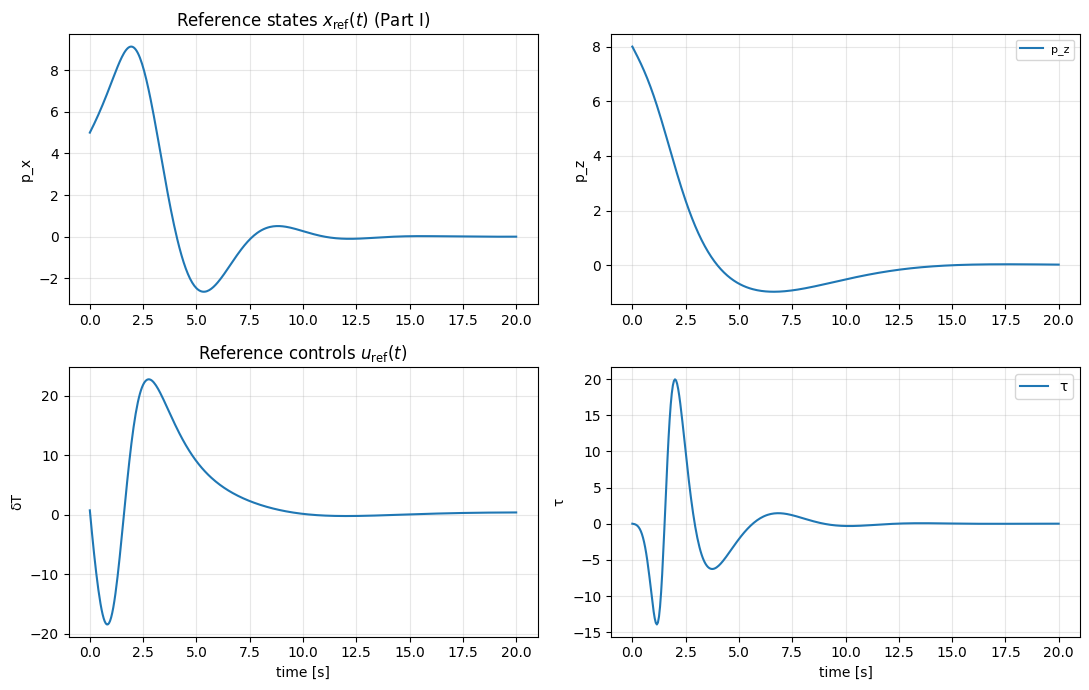

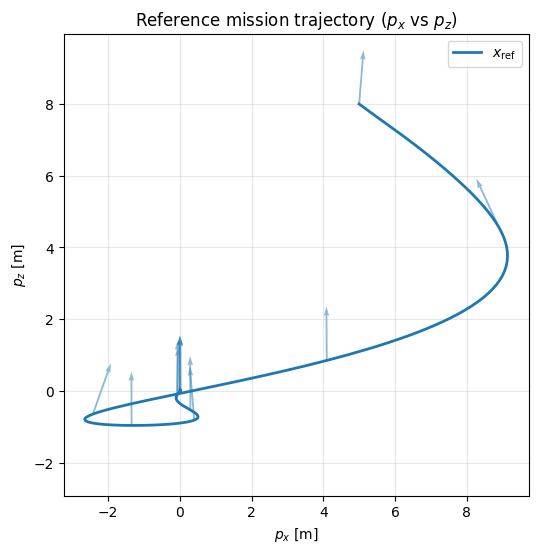

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for i, ax in enumerate(axes[0]):
    ax.plot(t, xref[:, i], label=STATE_LABELS[i])
    ax.set_ylabel(STATE_LABELS[i])
    ax.grid(True, alpha=0.3)
axes[0, 0].set_title("Reference states $x_{\\mathrm{ref}}(t)$ (Part I)")
axes[0, 1].legend(fontsize=8, ncol=2)

for j, ax in enumerate(axes[1]):
    ax.plot(t, uref[:, j], label=CTRL_LABELS[j])
    ax.set_xlabel("time [s]")
    ax.set_ylabel(CTRL_LABELS[j])
    ax.grid(True, alpha=0.3)
axes[1, 0].set_title("Reference controls $u_{\\mathrm{ref}}(t)$")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Mission-style plot: horizontal vs vertical position with attitude ticks
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(xref[:, 0], xref[:, 1], "C0-", lw=2, label="$x_{\\mathrm{ref}}$")
step = max(len(t) // 12, 1)
for k in range(0, len(t), step):
    th = xref[k, 4]
    ax.quiver(
        xref[k, 0], xref[k, 1],
        1.5 * np.sin(th), 1.5 * np.cos(th),
        angles="xy", scale_units="xy", scale=1, color="C0", alpha=0.5, width=0.004
    )
ax.set_xlabel("$p_x$ [m]")
ax.set_ylabel("$p_z$ [m]")
ax.set_title("Reference mission trajectory ($p_x$ vs $p_z$)")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Step 2 — Solve the tracking Riccati pair and simulate

Tracking uses $P(t_f)=0$, $s(t_f)=0$. The feedforward $s(t)$ encodes the **preview** of the future reference — without it, a pure feedback $u=-K(x-x_{\mathrm{ref}})$ would be suboptimal for the absolute-control penalty $u^\top R u$.

We deliberately choose a **large** tracking initial condition:

In [5]:
# Part II tracking Riccati (P(tf)=0)
P_trk_interp, _, P_trk_hist = lqr.solve_riccati_backward(
    dynamics_func, t, Q, R, np.zeros((7, 7)), params
)
s_interp, _, s_hist, xref_interp = lqr.solve_tracking_feedforward(
    dynamics_func, t, Q, R, xref, P_trk_interp, params
)

# Substantially different IC — simulates arriving at a new mission phase with large error
x0_track = np.array([-12.0, 15.0, -4.0, 3.0, -0.25, 0.4, -0.8])

print("Initial tracking error ||x0 - xref(0)|| =", np.linalg.norm(x0_track - xref[0]))
print("For comparison, reference IC norm ||x0_ref|| =", np.linalg.norm(x0_ref))

trk_ctrl = lambda tt, xx: lqr.tracking_control(
    tt, xx, xref_interp(tt), dynamics_func, P_trk_interp, s_interp, Q, R, params
)[0]
x_trk, u_trk = lqr.simulate_lti_closed_loop(A, B, t, trk_ctrl, x0_track)
err = x_trk - xref
J_trk = lqr.tracking_cost(x_trk, u_trk, xref, Q, R, t)

print(f"Tracking cost J_trk = {J_trk:.2f}")

Initial tracking error ||x0 - xref(0)|| = 19.8929359321343
For comparison, reference IC norm ||x0_ref|| = 9.764548120624937
Tracking cost J_trk = 6222.55


## Tracking performance

Metrics:
- **RMS tracking error** per state and overall
- **Peak error** during the transient
- **Final error** at $t_f$ (should be small if the controller succeeds)
- **Error energy** $\int_0^{t_f} (x-x_{\mathrm{ref}})^\top Q (x-x_{\mathrm{ref}})\,dt$

Per-state tracking diagnostics
 state         RMS        peak     |e(tf)|
   p_x      10.842      28.755       3.133
   p_z      10.985      23.243       0.559
   v_x       4.838      12.865       1.787
   v_z       2.898       5.939       0.086
     θ       0.382       1.252       0.071
     ω       0.393       1.324       0.326
     m       0.507       1.164       0.278

Overall RMS = 16.449


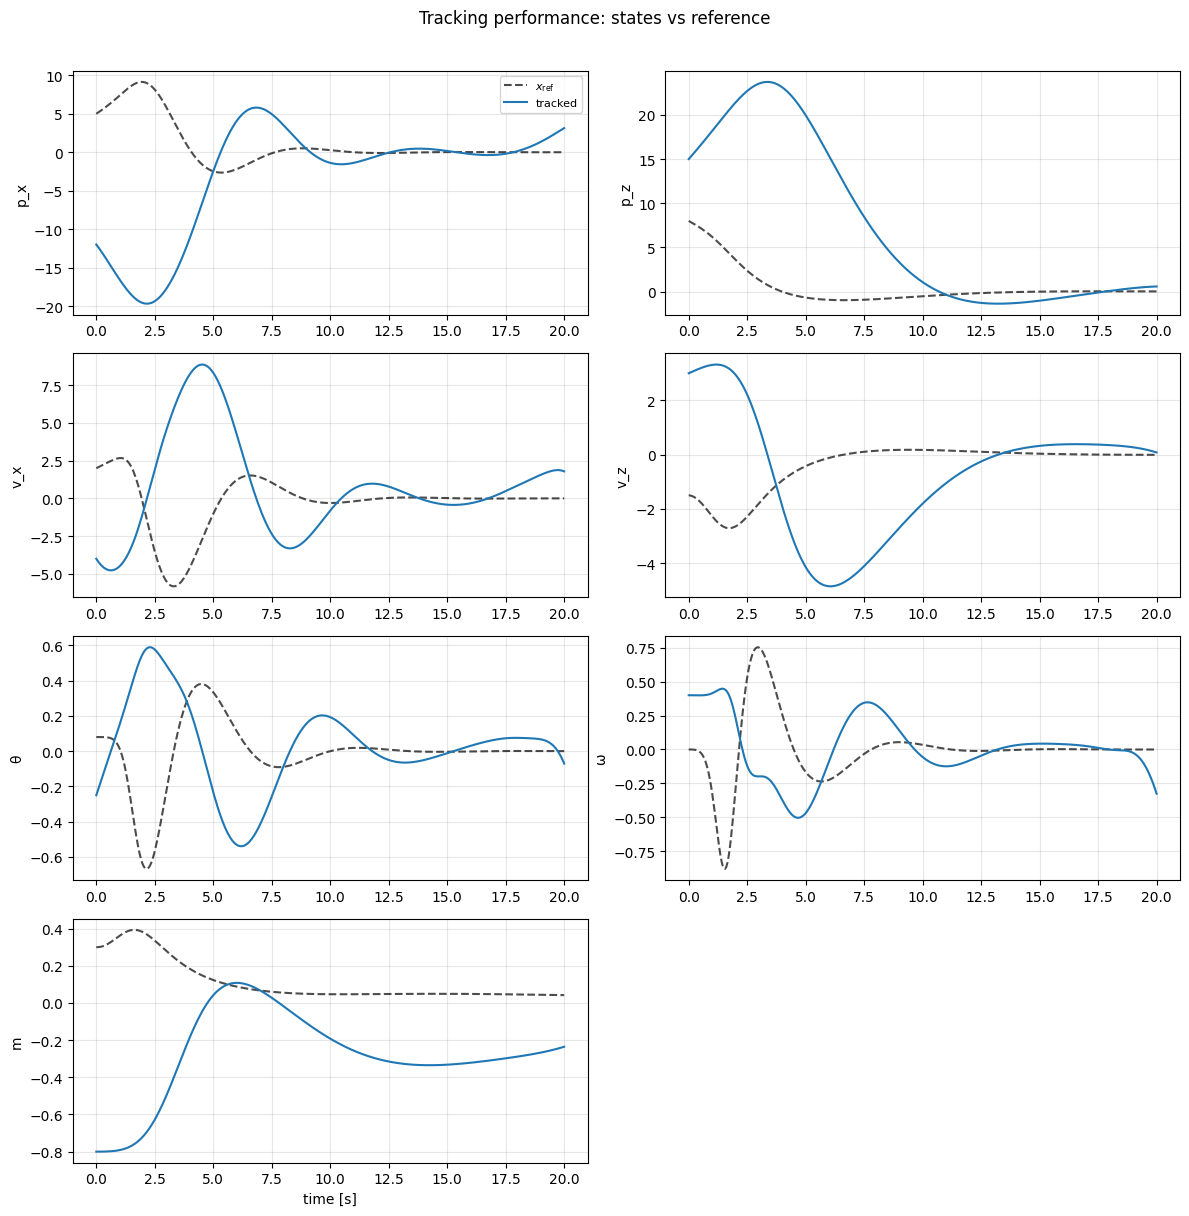

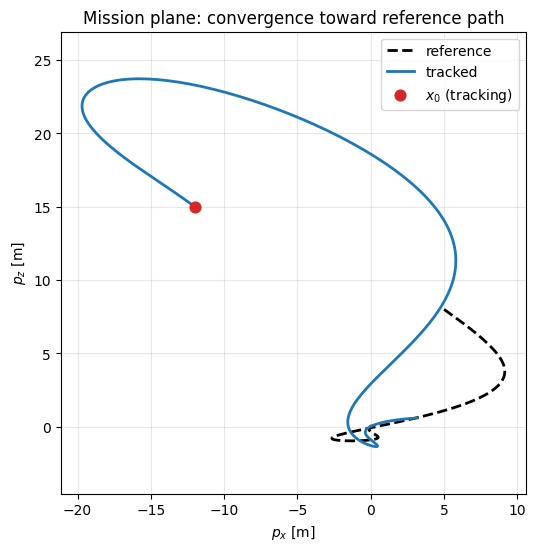

In [6]:
rms_err = np.sqrt(np.mean(err**2, axis=0))
peak_err = np.max(np.abs(err), axis=0)
final_err = np.abs(err[-1])

print("Per-state tracking diagnostics")
print(f"{'state':>6}  {'RMS':>10}  {'peak':>10}  {'|e(tf)|':>10}")
for i, lab in enumerate(STATE_LABELS):
    print(f"{lab:>6}  {rms_err[i]:10.3f}  {peak_err[i]:10.3f}  {final_err[i]:10.3f}")
print(f"\nOverall RMS = {np.linalg.norm(rms_err):.3f}")

fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.ravel()
for i in range(7):
    axes[i].plot(t, xref[:, i], "k--", alpha=0.7, label="$x_{\\mathrm{ref}}$")
    axes[i].plot(t, x_trk[:, i], "C0", label="tracked")
    axes[i].set_ylabel(STATE_LABELS[i])
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].legend(fontsize=8)
axes[6].set_xlabel("time [s]")
axes[7].axis("off")
plt.suptitle("Tracking performance: states vs reference", y=1.01)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(xref[:, 0], xref[:, 1], "k--", lw=2, label="reference")
ax.plot(x_trk[:, 0], x_trk[:, 1], "C0", lw=2, label="tracked")
ax.scatter([x0_track[0]], [x0_track[1]], c="C3", s=60, zorder=5, label="$x_0$ (tracking)")
ax.set_xlabel("$p_x$ [m]")
ax.set_ylabel("$p_z$ [m]")
ax.set_title("Mission plane: convergence toward reference path")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Transient response

We examine **how fast** the tracking error decays and whether any states overshoot.

Key components:
- $K(t)(x-x_{\mathrm{ref}})$ — **feedback** that stabilizes the error dynamics $\dot e = (A-BK)e$
- $R^{-1}B^\top s(t)$ — **feedforward** that anticipates the reference motion

The closed-loop error dynamics are approximately $\dot e \approx (A - BK)e$ when $x\approx x_{\mathrm{ref}}$; the feedforward handles the bulk of the reference-following burden early in the horizon.

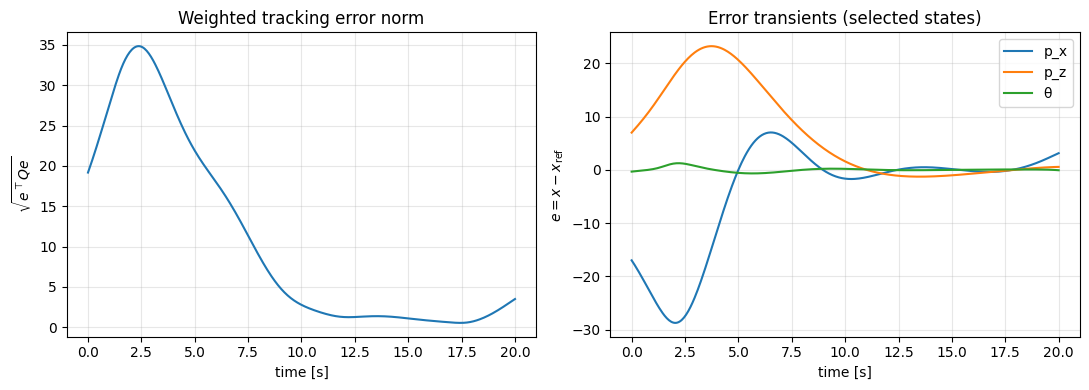

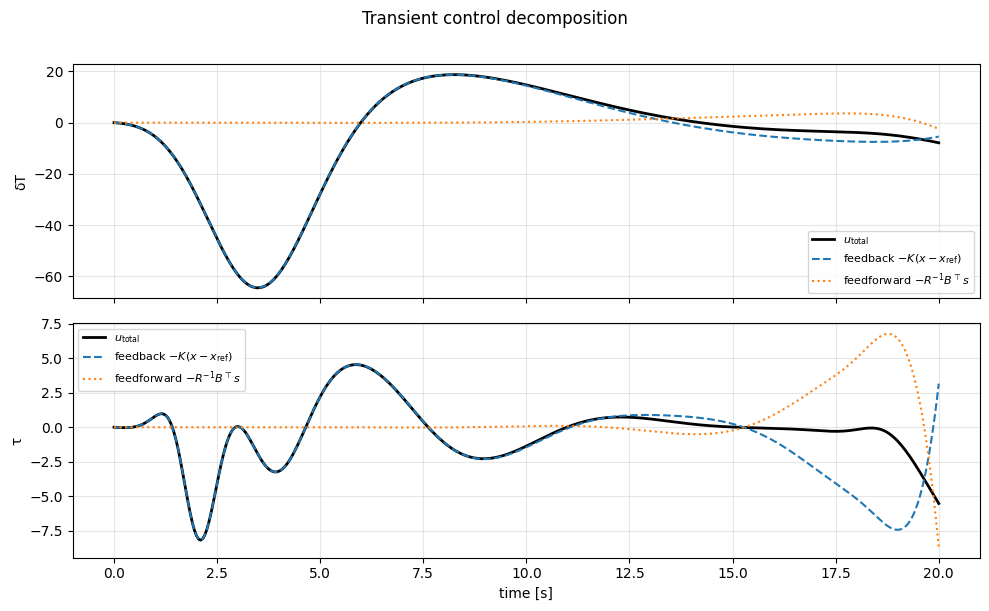

In [7]:
weighted_err = np.sqrt(np.einsum("ti,tij,tj->t", err, np.broadcast_to(Q, (len(t), 7, 7)), err))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t, weighted_err, "C0")
axes[0].set_xlabel("time [s]")
axes[0].set_ylabel(r"$\sqrt{e^\top Q e}$")
axes[0].set_title("Weighted tracking error norm")
axes[0].grid(True, alpha=0.3)

for i in [0, 1, 4]:
    axes[1].plot(t, err[:, i], label=STATE_LABELS[i])
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("$e = x - x_{\\mathrm{ref}}$")
axes[1].set_title("Error transients (selected states)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Decompose control into feedback vs feedforward contributions at each time
u_ff = np.zeros((len(t), 2))
u_fb = np.zeros((len(t), 2))
Rinv = np.linalg.inv(R)
for k, tt in enumerate(t):
    Ak, Bk = dynamics_func(tt, params)
    Pk = P_trk_interp(tt)
    sk = s_interp(tt)
    Kk = Rinv @ Bk.T @ Pk
    u_fb[k] = -Kk @ (x_trk[k] - xref[k])
    u_ff[k] = -Rinv @ Bk.T @ sk

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for j in range(2):
    axes[j].plot(t, u_trk[:, j], "k", lw=2, label="$u_{\\mathrm{total}}$")
    axes[j].plot(t, u_fb[:, j], "C0--", label="feedback $-K(x-x_{\\mathrm{ref}})$")
    axes[j].plot(t, u_ff[:, j], "C1:", label="feedforward $-R^{-1}B^\\top s$")
    axes[j].set_ylabel(CTRL_LABELS[j])
    axes[j].grid(True, alpha=0.3)
    axes[j].legend(fontsize=8)
axes[1].set_xlabel("time [s]")
plt.suptitle("Transient control decomposition", y=1.01)
plt.tight_layout()
plt.show()

## Control effort

Compare thrust/torque usage between:
1. **Reference regulation** (Part I plan)
2. **Tracking** from the perturbed IC

The tracking controller typically requires **more aggressive control early** to cancel the large initial error, then settles toward the reference control profile.

Control energy ∫ ||u||² dt  —  reference: 1694.8,  tracking: 10031.5
R-weighted control cost (tracking) = 1090.4


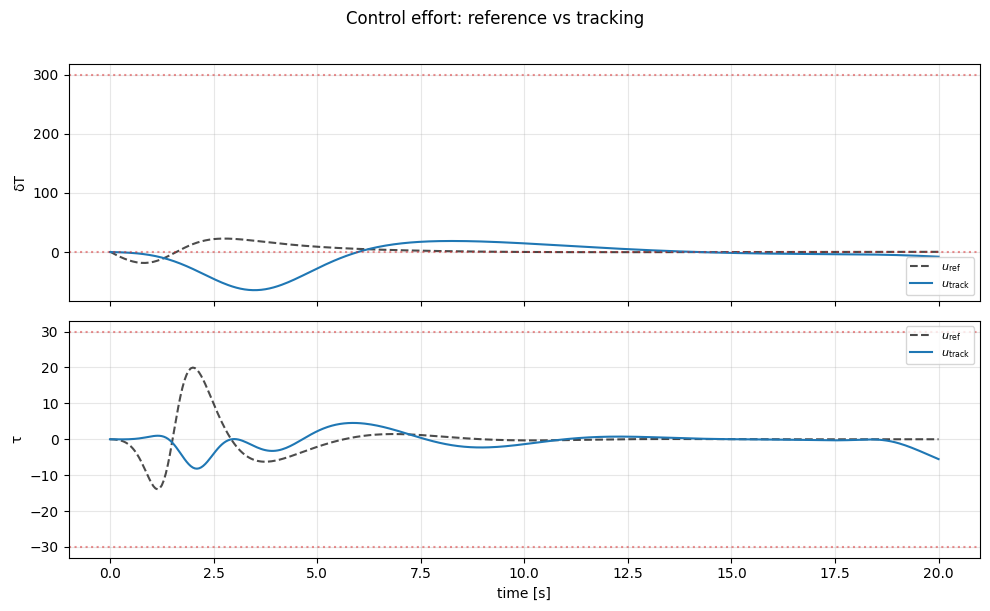

In [8]:
def control_energy(u_hist, t_grid):
    dt = np.diff(t_grid)
    return np.sum(0.5 * (np.linalg.norm(u_hist[:-1], axis=1)**2 + np.linalg.norm(u_hist[1:], axis=1)**2) * dt)

E_ref = control_energy(uref, t)
E_trk = control_energy(u_trk, t)
print(f"Control energy ∫ ||u||² dt  —  reference: {E_ref:.1f},  tracking: {E_trk:.1f}")
print(f"R-weighted control cost (tracking) = {np.einsum('ti,tij,tj->', u_trk, np.broadcast_to(R,(len(t),2,2)), u_trk) * (tf/len(t)):.1f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for j in range(2):
    axes[j].plot(t, uref[:, j], "k--", alpha=0.7, label="$u_{\\mathrm{ref}}$")
    axes[j].plot(t, u_trk[:, j], "C0", label="$u_{\\mathrm{track}}$")
    axes[j].axhline(params["τ_max" if j == 1 else "T_max"], color="C3", ls=":", alpha=0.5)
    axes[j].axhline(params["τ_min" if j == 1 else "T_min"], color="C3", ls=":", alpha=0.5)
    axes[j].set_ylabel(CTRL_LABELS[j])
    axes[j].grid(True, alpha=0.3)
    axes[j].legend(fontsize=8)
axes[1].set_xlabel("time [s]")
plt.suptitle("Control effort: reference vs tracking", y=1.01)
plt.tight_layout()
plt.show()

## Robustness to deviations from the nominal trajectory

We test sensitivity along two axes required by the project:

1. **Initial-condition sweep** — scale the tracking IC $x_0(\alpha) = x_{0,\mathrm{ref}} + \alpha\,\Delta x$ with $\Delta x = x_{0,\mathrm{track}} - x_{0,\mathrm{ref}}$.
2. **Reference perturbation** — add noise to $x_{\mathrm{ref}}(t)$ and re-solve the feedforward ODE (simulates a imperfectly known plan).

For each case we report the terminal error $\|x(t_f)-x_{\mathrm{ref}}(t_f)\|$ and total tracking cost.

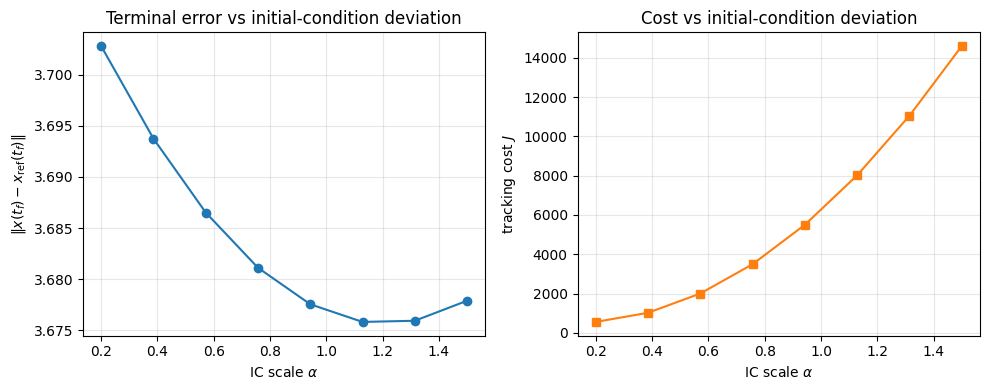

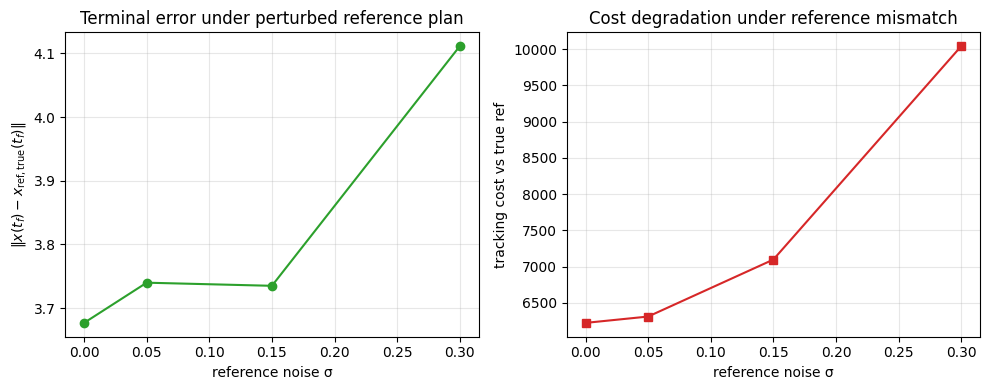

In [9]:
delta_x0 = x0_track - x0_ref
alphas = np.linspace(0.2, 1.5, 8)
term_err_ic = []
cost_ic = []

for alpha in alphas:
    x0_test = x0_ref + alpha * delta_x0
    x_test, u_test = lqr.simulate_lti_closed_loop(A, B, t, trk_ctrl, x0_test)
    term_err_ic.append(np.linalg.norm(x_test[-1] - xref[-1]))
    cost_ic.append(lqr.tracking_cost(x_test, u_test, xref, Q, R, t))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(alphas, term_err_ic, "o-")
axes[0].set_xlabel(r"IC scale $\alpha$")
axes[0].set_ylabel(r"$\|x(t_f)-x_{\mathrm{ref}}(t_f)\|$")
axes[0].set_title("Terminal error vs initial-condition deviation")
axes[0].grid(True, alpha=0.3)

axes[1].plot(alphas, cost_ic, "s-", color="C1")
axes[1].set_xlabel(r"IC scale $\alpha$")
axes[1].set_ylabel("tracking cost $J$")
axes[1].set_title("Cost vs initial-condition deviation")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Reference perturbation: noisy plan -> recompute s(t)
rng = np.random.default_rng(42)
noise_levels = [0.0, 0.05, 0.15, 0.30]
term_err_ref = []
cost_ref = []

for sigma in noise_levels:
    xref_noisy = xref + sigma * rng.standard_normal(xref.shape)
    s_noisy_interp, _, _, xref_noisy_interp = lqr.solve_tracking_feedforward(
        dynamics_func, t, Q, R, xref_noisy, P_trk_interp, params
    )
    ctrl_noisy = lambda tt, xx, si=s_noisy_interp, xi=xref_noisy_interp: lqr.tracking_control(
        tt, xx, xi(tt), dynamics_func, P_trk_interp, si, Q, R, params
    )[0]
    x_n, u_n = lqr.simulate_lti_closed_loop(A, B, t, ctrl_noisy, x0_track)
    term_err_ref.append(np.linalg.norm(x_n[-1] - xref[-1]))  # error vs TRUE reference
    cost_ref.append(lqr.tracking_cost(x_n, u_n, xref, Q, R, t))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(noise_levels, term_err_ref, "o-", color="C2")
axes[0].set_xlabel("reference noise σ")
axes[0].set_ylabel(r"$\|x(t_f)-x_{\mathrm{ref,true}}(t_f)\|$")
axes[0].set_title("Terminal error under perturbed reference plan")
axes[0].grid(True, alpha=0.3)

axes[1].plot(noise_levels, cost_ref, "s-", color="C3")
axes[1].set_xlabel("reference noise σ")
axes[1].set_ylabel("tracking cost vs true ref")
axes[1].set_title("Cost degradation under reference mismatch")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Regulation vs tracking — comparison table

| Aspect | Part I regulation | Part II tracking |
|--------|-------------------|------------------|
| Cost integrand | $x^\top Q x + u^\top R u$ | $(x-x_{\mathrm{ref}})^\top Q (x-x_{\mathrm{ref}}) + u^\top R u$ |
| Terminal condition | $\lambda(t_f)=2Q_f x(t_f)$ | $\lambda(t_f)=0$, $P(t_f)=0$ |
| Optimal control | $u=-K(t)x$ | $u=-K(t)(x-x_{\mathrm{ref}}) - R^{-1}B^\top s$ |
| Extra ODE | Riccati only | Riccati + feedforward $s$ |
| Role | Return to trim | Follow a pre-planned segment |

---

## Discussion: What if the reference is not known in advance?

The current approach assumes $x_{\mathrm{ref}}(t)$ and (implicitly) the corresponding nominal control are **fully known over the entire horizon** $[0,t_f]$ before the tracking phase begins. This is appropriate when a prior optimal planner (Part I / mission optimizer) has already produced the reference.

**Challenges when the reference is unknown or only partially known:**

1. **Feedforward term $s(t)$ requires preview.** The tracking Riccati derivation integrates $-\dot s = A_{\mathrm{cl}}^\top s + Q x_{\mathrm{ref}}$ backward using the *entire* future reference. Without preview, you must fall back to **receding-horizon LQR** (re-solve every $\Delta t$ with updated measurements) or **steady-state LQR** ($P$ from ARE) which is only optimal for regulation to a constant setpoint.

2. **LTV matrices depend on the nominal path.** For descent (Part I.5.2), $A(t),B(t)$ are tied to trim along $x_{\mathrm{ref}}$. If the true trajectory deviates, the linearization point is wrong — the computed $K(t)$ is **scheduled for the wrong plant**, hurting robustness (especially horizontal motion where controllability is weak).

3. **No online replanning.** Large disturbances may make the reference unreachable within remaining fuel/horizon; this open-loop-in-reference controller has no mechanism to detect infeasibility or re-optimize.

4. **State constraints ignored.** Altitude $p_z\ge 0$ and mass floors are not enforced in the quadratic tracker; a disturbed vehicle could track the reference into the ground unless outer loops or constrained MPC wrap this controller.

**Practical mitigations:** model predictive control (MPC), iterative re-linearization along the *actual* path, disturbance observers, or gain scheduling with measured state instead of planned state for the trim point.

---

### Optional extension: LTV descent tracking

Swap `dynamics_func = dyn.get_descent_dynamics` and replace `simulate_lti_closed_loop` with `simulate_ltv_closed_loop`. The Riccati/feedforward solvers in `lqr.py` already accept time-varying $A(t),B(t)$. Expect **larger terminal errors** late in the horizon when horizontal controllability deteriorates (see Part I Gramian analysis).